# Using the Custom Dataset Object

This notebook entails the main features of our custom-made dataset object.

This makes ResNet development much easier, and allows for more customization as well as manipulating the data structure to our benefit.

In [46]:
# Configuration file for the project (directories)
from config import *
from utils import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# A Global Overview

We wanted to be able to evolve this project sequentially. That will most likely imply the progressive increase in difficulty for both discriminator and generator. In order to do so, there are multiple essential features to take into consideration:

1. Fast and convenient data observation
2. Trivial fold manipulation
3. Easy labeling setup
4. Automatically fulfilling ResNet structural requirements 




## Creating an Instance

Creating a raw instance by passing a directory will read every image with the approved extensions (see in [utils.py](utils.py))

In [47]:
ds_fold0 = DeepFakeDataset(WIKI_DIR+"/00", "true_image")

The main functions return basic information, such as the item itself and the entire dataset's length (`__getitem__`, `__len__`).

It's important to mention that each instance is composed of its numpy array image representation, label, fold identifier and the file name from which the information is derived. These all have a formatted output which can be obtained by using  

```py 
show(self, idx)
```

In [48]:
len(ds_fold0)

281

true_image 00 10049200_1891-09-16_1958.jpg


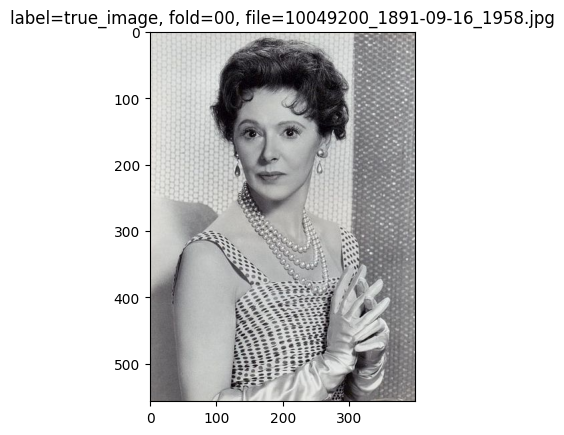

label=true_image, fold=00, file=10049200_1891-09-16_1958.jpg


In [49]:
img, label, fold, filename = ds_fold0[0]

print(label, fold, filename)

img_check = ds_fold0.show(0)

## Building Dataset Based on Folds

Here, we're going to be using the following function:



```py 
def buildDsFolds(img_dir, range_folds=[0,5], label=0, transform=resnetFormat(), range=True): 
```


For starters, fold operations:
1. To include the entire dataset, use `range_folds = [0,100]`
2. To inlcude sequential subsample of the dataset, spanning from `folds_start` to `folds_end` use `range_folds = [folds_start,range_folds]`
3. To include a specific subset of scattered folds, pass folds as integer inside `range_folds` and disable `range` (`range=False`)

Regarding labeling:
1. Combine the afforementioned techniques with manual labeling and posterior `ConcatDataset(datasets)`

And formatting:
1. Implicitly applies transformation to tensor as well as resizing (for consistency and computational efficiency)

In [50]:
ds_wiki = buildDsFolds(WIKI_DIR, range_folds=[0,100])

Building ../deepfake_data/wiki dataset with 100 folds: 100%|██████████| 100/100 [00:00<00:00, 1622.96it/s]


As can be seen, it's quite fast! Let's check standard properties:

In [51]:
len(ds_wiki)

30000

In [52]:
img_wiki = ds_wiki.show(0)

AttributeError: 'ConcatDataset' object has no attribute 'show'